In [94]:
import json
import pandas as pd
import os
from benchmarks import load_cbenchio_reports,get_report_filenames,load_reframe_report,get_performance_tables,get_file_system
from matplotlib import pyplot as plt
import seaborn as sns
import re
import numpy as np
sns.set_style("whitegrid")

base_path="../../results"


# Results from syntethic benchmarks using cbenchio

## MPI-IO 1D

In [74]:
filenames= ["mpi1DLustreN1-16T1-288Snum_nodesF4-32M.json","mpi1DVastN1-16T1-288Snum_nodesF4-32M.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
data["field_size_per_process_per_dimension"]/=2**20
data

,name,nodes,tasks_per_node,base_path,api,stripes,field_size_per_process_per_dimension,bandwidth,filesystem
0,cbenchio_mpi_1D_write,1,1,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,1,4.0,0.278684,lustre
1,cbenchio_mpi_1D_write,1,1,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,1,16.0,0.935032,lustre
2,cbenchio_mpi_1D_write,1,1,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,1,32.0,1.076893,lustre
3,cbenchio_mpi_1D_write,1,2,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,1,4.0,0.722016,lustre
4,cbenchio_mpi_1D_write,1,2,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,1,16.0,1.285103,lustre
...,...,...,...,...,...,...,...,...,...
3592,cbenchio_mpi_1D_read,16,8,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,16,16.0,8.284323,lustre
3593,cbenchio_mpi_1D_read,16,8,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,16,32.0,11.267759,lustre
3594,cbenchio_mpi_1D_read,16,24,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,16,4.0,7.512543,lustre
3595,cbenchio_mpi_1D_read,16,24,/work/z19/z19/lparisi/nfs-testing/run/data,mpi,16,16.0,14.334925,lustre


### Single node performance

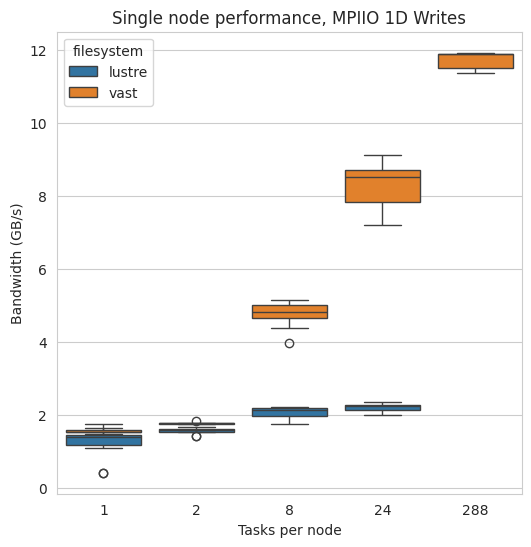

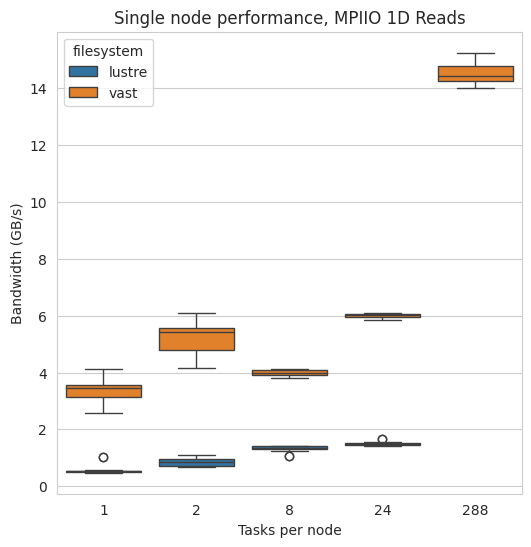

In [75]:
for operation in ["write","read"]:
    fix,ax = plt.subplots(figsize=(6, 6))
    plot_data = data.query(f"nodes==1 & field_size_per_process_per_dimension=={32} & stripes == 1 & name=='cbenchio_mpi_1D_{operation}'")
    sns.boxplot(data=plot_data, x="tasks_per_node", y="bandwidth", hue="filesystem",dodge=False)
    plt.savefig(f"single_node_performance_mpi_1D_{operation}.png", dpi=300, bbox_inches="tight")
    ax.set_title(f"Single node performance, MPIIO 1D {operation.capitalize()}s")
    ax.set_ylabel("Bandwidth (GB/s)")
    ax.set_xlabel("Tasks per node")



/tmp/ipykernel_289833/1294787328.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["tasks_per_node"]=plot_data["tasks_per_node"].astype(str)
/tmp/ipykernel_289833/1294787328.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["tasks_per_node"]=plot_data["tasks_per_node"].astype(str)
/tmp/ipykernel_289833/1294787328.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

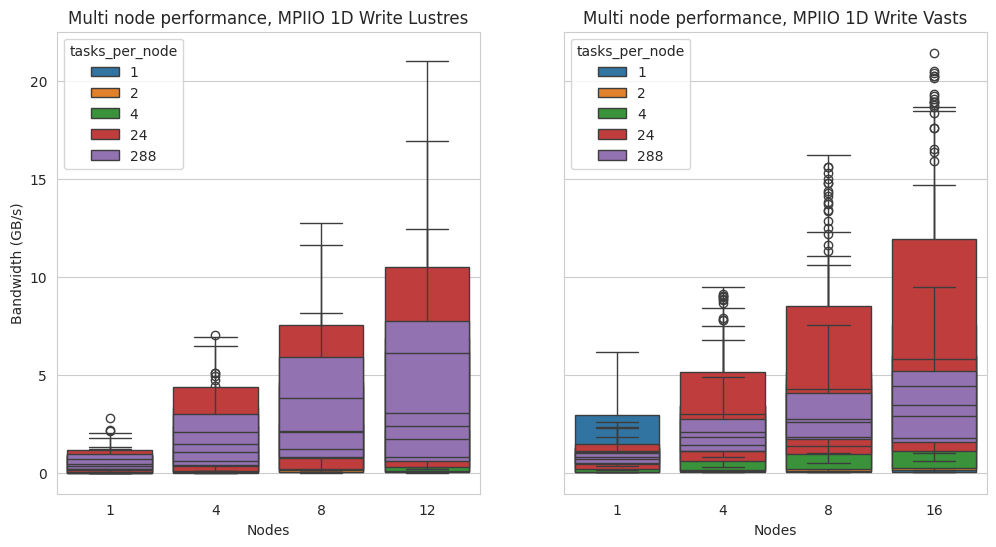

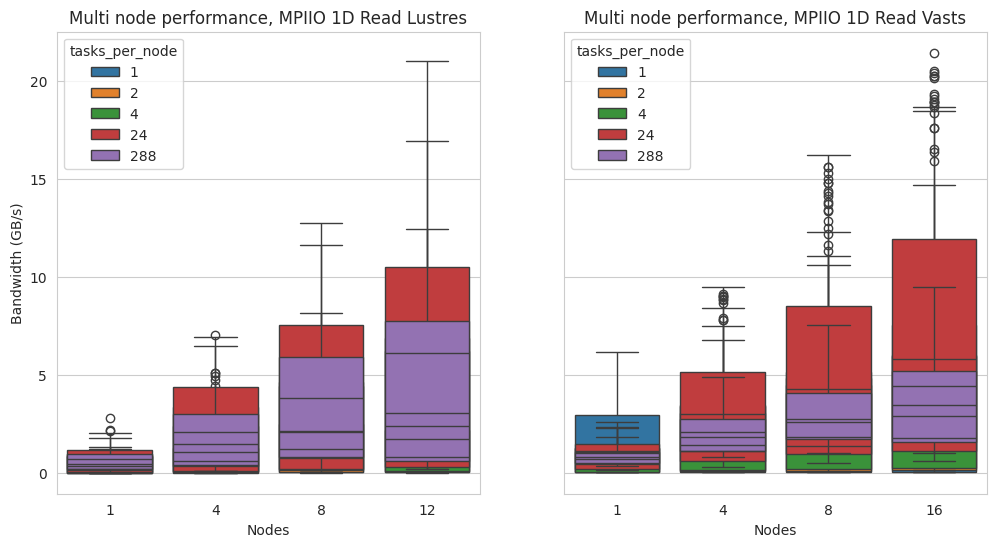

In [81]:
for operation in ["write","read"]:
    fix,ax = plt.subplots(1, 2, figsize=(12, 6),sharey=True)
    for i,filesystem in enumerate(["lustre","vast"]):
        plot_data = data.query(f" field_size_per_process_per_dimension==32 & name=='cbenchio_mpi_1D_{operation}'")
        plot_data=data.query(f"filesystem=='{filesystem}' ")
        plot_data["tasks_per_node"]=plot_data["tasks_per_node"].astype(str)
        sns.boxplot(data=plot_data, x="nodes", y="bandwidth", hue="tasks_per_node",dodge=False,ax=ax[i])
        ax[i].set_title(f"Multi node performance, MPIIO 1D {operation.capitalize()} {filesystem.capitalize()}s")
        ax[i].set_ylabel("Bandwidth (GB/s)")
        ax[i].set_xlabel("Nodes")
    plt.savefig(f"multi_node_performance_mpi_1D_{operation}.png", dpi=300, bbox_inches="tight")

## MPI 3D array

In [95]:
filenames= ["mpi3DVastN1-16T1-288F4-32M.json","mpi3DLustreN1-16T1-288F4-32M.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
set(data["filesystem"])
data

,name,nodes,tasks_per_node,base_path,api,stripes,field_size_per_process_per_dimension,bandwidth,filesystem
0,cbenchio_mpi_3D_write,1,1,/vast/lparisi/data,mpi,1,128,0.013894,vast
1,cbenchio_mpi_3D_write,1,1,/vast/lparisi/data,mpi,1,512,0.444223,vast
2,cbenchio_mpi_3D_write,1,1,/vast/lparisi/data,mpi,1,2048,2.936202,vast
3,cbenchio_mpi_3D_write,1,2,/vast/lparisi/data,mpi,1,128,0.017531,vast
4,cbenchio_mpi_3D_write,1,2,/vast/lparisi/data,mpi,1,512,0.543804,vast
...,...,...,...,...,...,...,...,...,...
2874,cbenchio_mpi_3D_read,16,24,/vast/lparisi/data,mpi,1,128,1.150663,vast
2875,cbenchio_mpi_3D_read,16,24,/vast/lparisi/data,mpi,1,512,13.430285,vast
2876,cbenchio_mpi_3D_read,16,24,/vast/lparisi/data,mpi,1,2048,16.957668,vast
2877,cbenchio_mpi_3D_read,16,288,/vast/lparisi/data,mpi,1,128,2.826502,vast


/tmp/ipykernel_289833/2111557247.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["field_size_per_process_per_dimension"]=plot_data["field_size_per_process_per_dimension"].astype(str)
/tmp/ipykernel_289833/2111557247.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["field_size_per_process_per_dimension"]=plot_data["field_size_per_process_per_dimension"].astype(str)
/tmp/ipykernel_289833/2111557247.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

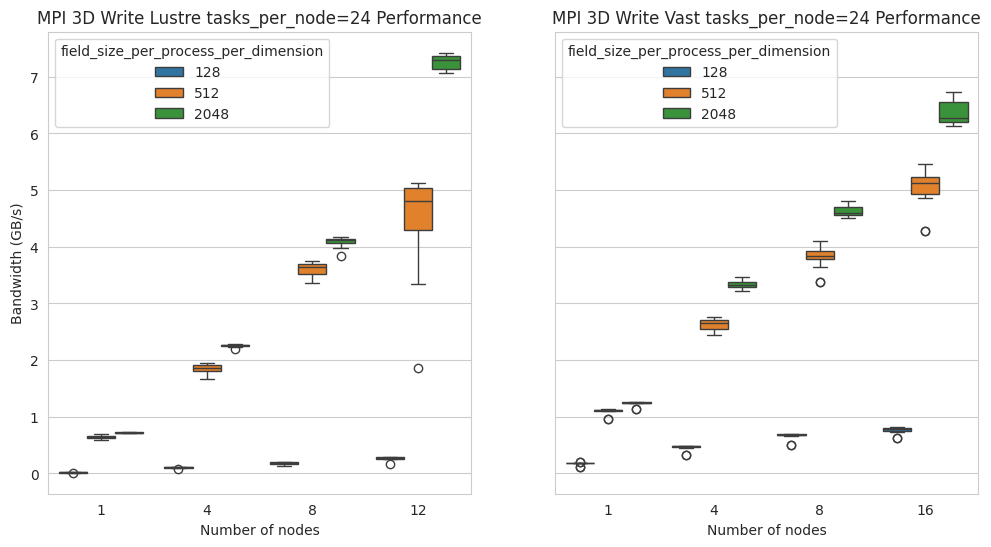

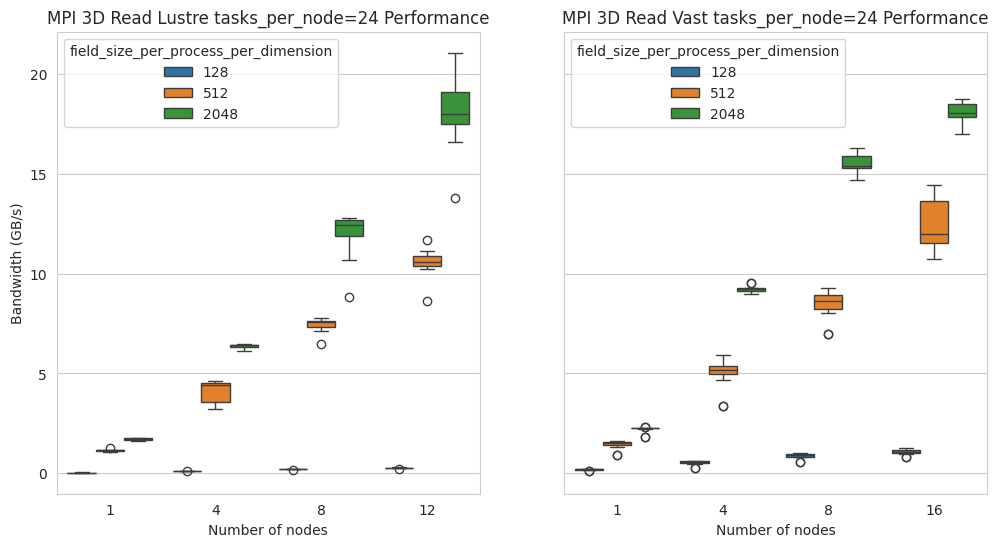

In [96]:
for i,operation in enumerate(["write","read"]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    tasks_per_node = 24
    for i,filesystem in enumerate(["lustre","vast"]):
        plot_data=data.query(f"name=='cbenchio_mpi_3D_{operation}' & filesystem=='{filesystem}' & tasks_per_node=={tasks_per_node}")
        plot_data["field_size_per_process_per_dimension"]=plot_data["field_size_per_process_per_dimension"].astype(str)
        if filesystem == "lustre":
            plot_data = plot_data.query("stripes==-1")
        #plot_data["chunk_size"]=(np.array(plot_data["chunk_size"]).astype(float).astype(int)).astype(str) + " KiB"
        sns.boxplot(ax=axes[i], data=plot_data, x="nodes", y="bandwidth", hue="field_size_per_process_per_dimension",dodge=True)
        axes[i].set_ylabel("Bandwidth (GB/s)")
        axes[i].set_xlabel("Number of nodes")
        axes[i].set_title(f"MPI 3D {operation.capitalize()} {filesystem.capitalize()} tasks_per_node={tasks_per_node} Performance")


    plt.savefig(f"mpi_3D_{operation}_tasks_perNode{tasks_per_node}.png", dpi=300, bbox_inches="tight")


## Sequential POSIX 

In [132]:
filenames= ["posixVASTN1T1-288C4K-32MF0.5G.json","posixLustreN1Sequential.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
data["chunk_size"]= (data["chunk_size"].astype(int)/2**10).astype(str)
data["chunk_size"]= [ chunk_size + " KiB"  for chunk_size in data["chunk_size"]]

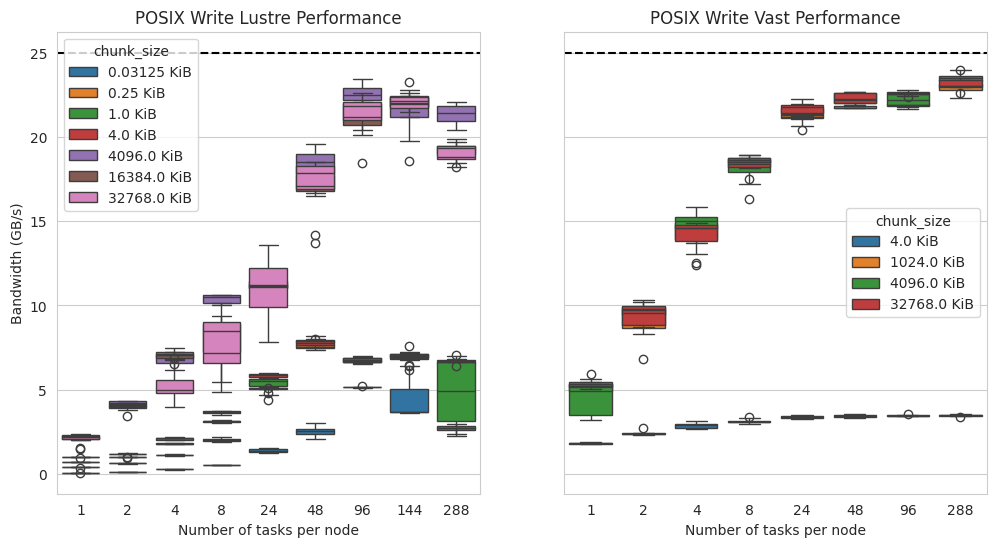

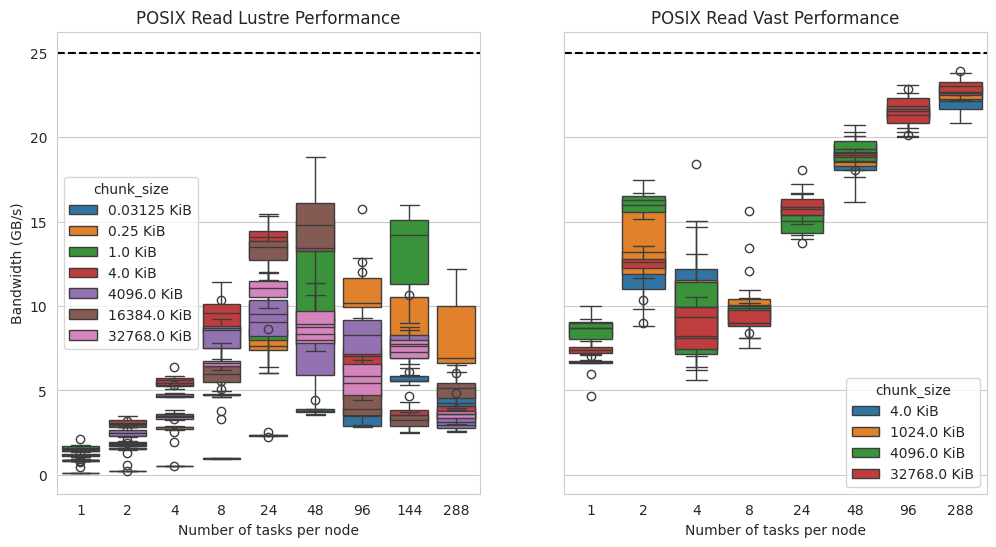

In [133]:

for i,operation in enumerate(["write","read"]):

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    for i,filesystem in enumerate(["lustre","vast"]):

        plot_data=data.query(f"name=='cbenchio_posix_sequential_{operation}'").query(f"filesystem=='{filesystem}'")
        plot_data["chunk_size"]=plot_data["chunk_size"].astype(str)
        sns.boxplot(ax=axes[i], data=plot_data, x="tasks_per_node", y="bandwidth", hue="chunk_size",dodge=False)
        axes[i].set_ylabel("Bandwidth (GB/s)")
        axes[i].set_xlabel("Number of tasks per node")
        axes[i].set_title(f"POSIX {operation.capitalize()} {filesystem.capitalize()} Performance")

        # Horizontal line at 25GB/s
        axes[i].axhline(y=25, color='black', linestyle='--')
        
        plt.savefig(f"single_node_performance_POSIX_{filesystem}.png", dpi=300, bbox_inches="tight")


In [141]:
filenames= ["posixVASTN1-16T1-288C4K-32MF0.5G.json","posixLustreN1-16T24C32M.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
data["chunk_size"]= (data["chunk_size"].astype(int)/2**10).astype(str)
data["chunk_size"]= [ chunk_size + " KiB"  for chunk_size in data["chunk_size"] ]

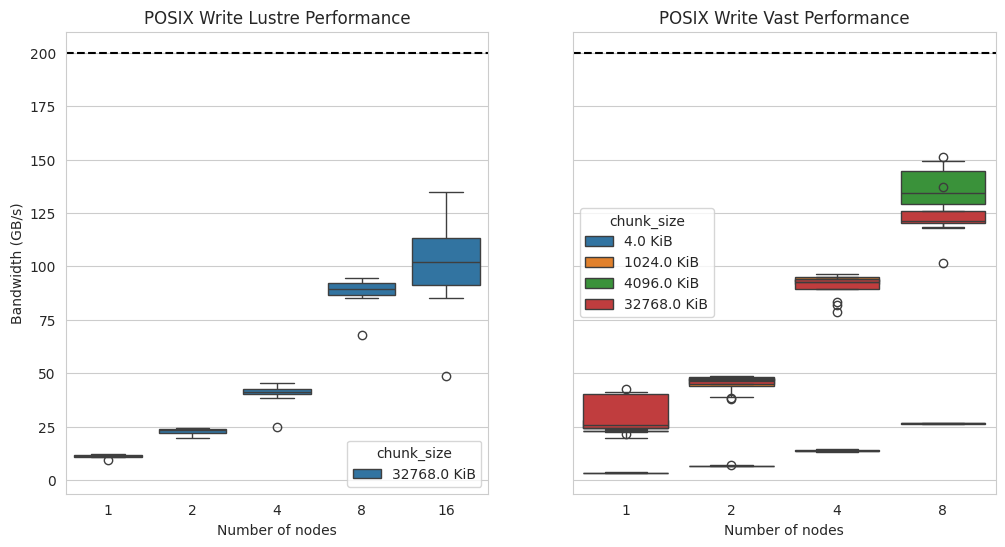

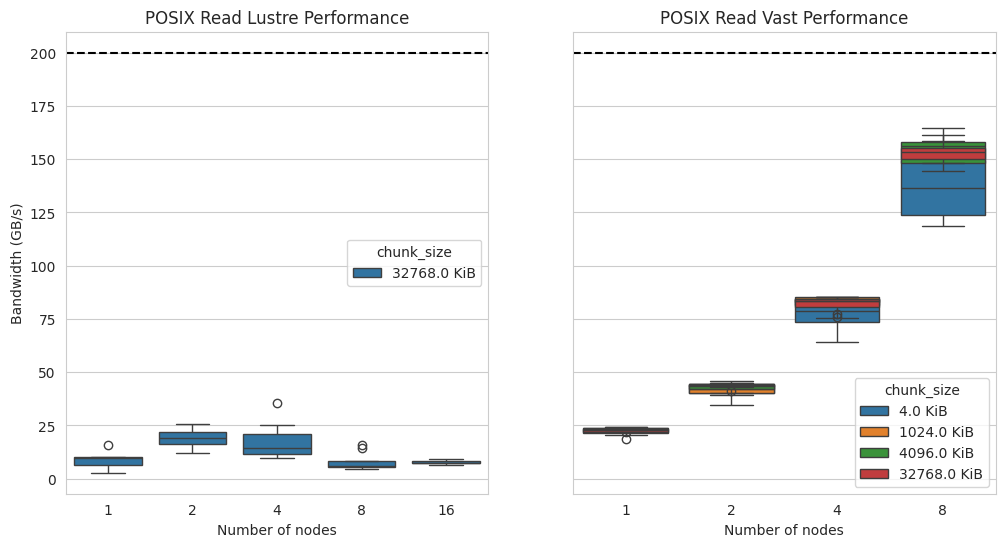

In [142]:
for i,operation in enumerate(["write","read"]):

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    for i,filesystem in enumerate(["lustre","vast"]):

        plot_data=data.query(f"name=='cbenchio_posix_sequential_{operation}'").query(f"filesystem=='{filesystem}'")
        plot_data["chunk_size"]=plot_data["chunk_size"].astype(str)
        selection = plot_data["tasks_per_node"]==np.max(plot_data["tasks_per_node"])
        plot_data = plot_data[selection]
        sns.boxplot(ax=axes[i], data=plot_data, x="nodes", y="bandwidth", hue="chunk_size",dodge=False)
        axes[i].set_ylabel("Bandwidth (GB/s)")
        axes[i].set_xlabel("Number of nodes")
        axes[i].set_title(f"POSIX {operation.capitalize()} {filesystem.capitalize()} Performance")

        # Horizontal line at 25GB/s
        axes[i].axhline(y=200, color='black', linestyle='--')
        
        plt.savefig(f"multi_node_performance_POSIX_{filesystem}.png", dpi=300, bbox_inches="tight")

## Random POSIX

In [143]:
filenames= ["posixLustreN1-16Random.json","posixVASTN1-16Random_2.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
selection = data["chunk_size"].astype(int) <= 1024
data["chunk_size"]= data["chunk_size"].astype(str)
data["chunk_size"]= [ chunk_size + " B"  for chunk_size in data["chunk_size"]]
data = data[selection] 
data

,name,nodes,tasks_per_node,base_path,api,chunk_size,field_size_per_process_per_dimension,bandwidth,stripes,filesystem
0,cbenchio_posix_random_write,1,1,/vast/data/lparisi/data,posix,128 B,65536,0.000172,1,vast
1,cbenchio_posix_random_write,1,1,/vast/data/lparisi/data,posix,256 B,65536,0.000338,1,vast
2,cbenchio_posix_random_write,1,1,/vast/data/lparisi/data,posix,1024 B,65536,0.003061,1,vast
4,cbenchio_posix_random_write,1,4,/vast/data/lparisi/data,posix,128 B,65536,0.000812,1,vast
5,cbenchio_posix_random_write,1,4,/vast/data/lparisi/data,posix,256 B,65536,0.001569,1,vast
...,...,...,...,...,...,...,...,...,...,...
3193,cbenchio_posix_random_read,16,24,/work/z19/z19/lparisi/nfs-testing/run/data,posix,256 B,65536,1.465713,1,lustre
3194,cbenchio_posix_random_read,16,24,/work/z19/z19/lparisi/nfs-testing/run/data,posix,1024 B,65536,1.829953,1,lustre
3196,cbenchio_posix_random_read,16,288,/work/z19/z19/lparisi/nfs-testing/run/data,posix,128 B,65536,16.873072,1,lustre
3197,cbenchio_posix_random_read,16,288,/work/z19/z19/lparisi/nfs-testing/run/data,posix,256 B,65536,14.346272,1,lustre


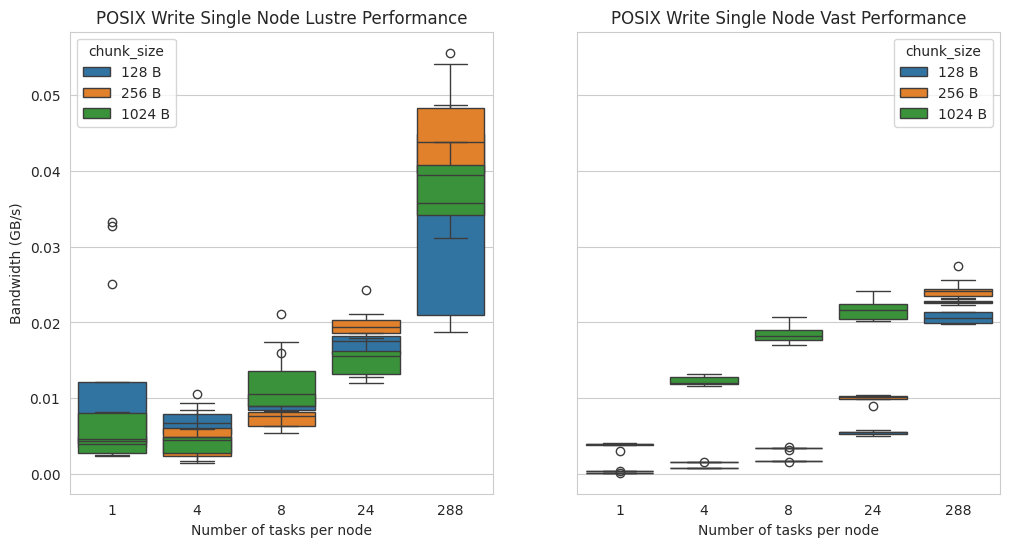

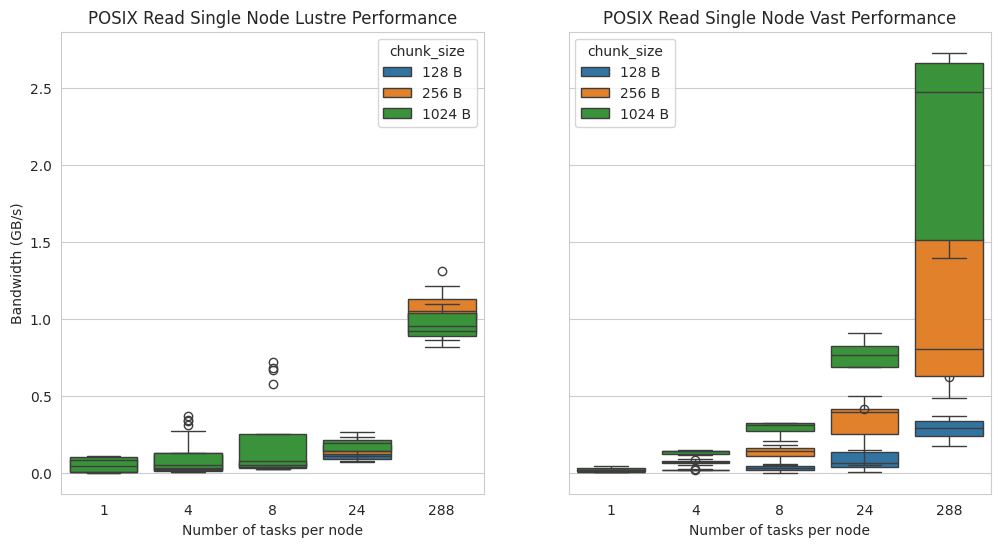

In [144]:
for i,operation in enumerate(["write","read"]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    for i,filesystem in enumerate(["lustre","vast"]):
        plot_data=data.query(f"name=='cbenchio_posix_random_{operation}'").query(f"filesystem=='{filesystem}'").query("nodes==1")
        #plot_data["chunk_size"]=(np.array(plot_data["chunk_size"]).astype(float).astype(int)).astype(str) + " KiB"
        sns.boxplot(ax=axes[i], data=plot_data, x="tasks_per_node", y="bandwidth", hue="chunk_size",dodge=False)
        axes[i].set_ylabel("Bandwidth (GB/s)")
        axes[i].set_xlabel("Number of tasks per node")
        axes[i].set_title(f"POSIX {operation.capitalize()} Single Node {filesystem.capitalize()} Performance")
    plt.savefig(f"single_node_performance_POSIX_{filesystem}_random.png", dpi=300, bbox_inches="tight")


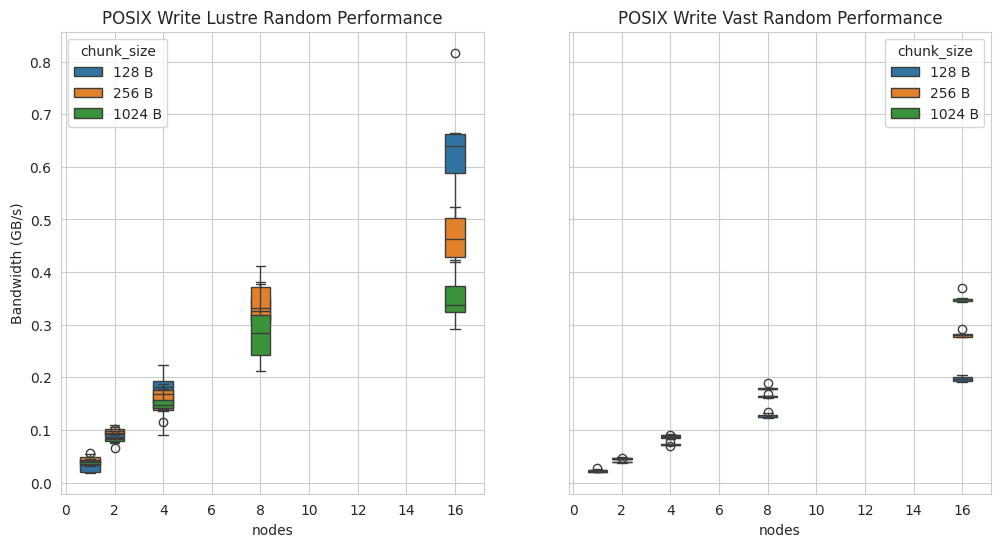

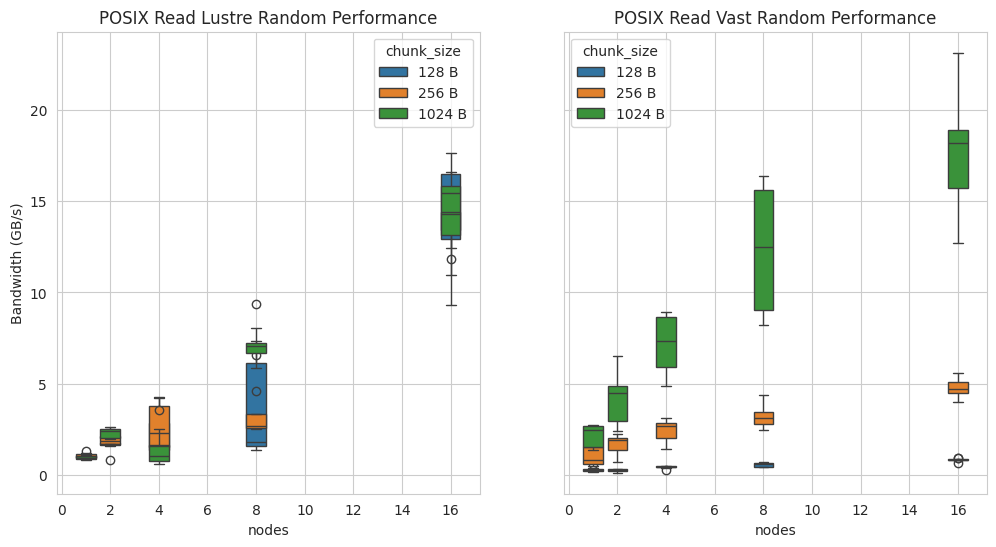

In [145]:
for i,operation in enumerate(["write","read"]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6),sharey=True)
    for i,filesystem in enumerate(["lustre","vast"]):
        plot_data=data.query(f"name=='cbenchio_posix_random_{operation}'" ).query("tasks_per_node==288").query(f"filesystem=='{filesystem}'")
        #plot_data["chunk_size"]=(np.array(plot_data["chunk_size"]).astype(float).astype(int)).astype(str) + " KiB"
        sns.boxplot(ax=axes[i], data=plot_data, x="nodes", y="bandwidth", hue="chunk_size",dodge=False,native_scale=True)
        axes[i].set_ylabel("Bandwidth (GB/s)")
        axes[i].set_xlabel("nodes")
        axes[i].set_title(f"POSIX {operation.capitalize()} {filesystem.capitalize()} Random Performance")


    plt.savefig(f"single_node_performance_posix_{operation}_random.png", dpi=300, bbox_inches="tight")

## Mdtest benchmarking
Overall metadata operations are about an order of magnitude faster on VAST, when processes are writing to different directories. However, the situation is reversed when writing to a single directory, with VAST being significantly faster on lustre.

In [146]:
## Multiple directories
files=["mdtestMultipleSingleDirectories.json"]
for file in files:
    data=load_reframe_report(os.path.join(base_path,file))
    data=get_performance_tables(data)
data=pd.concat(data).reset_index(drop=True)
data["filesystem"]= [get_file_system(path) for path in data["work_directory"]]
#data.pivot(columns=["file_creation_mean"])
data=data.filter(items=["name","nodes","filesystem","tasks_per_node","file_creation_mean","file_stat_mean","file_removal_mean"])
data=pd.melt(data, id_vars=["name","nodes","filesystem","tasks_per_node"], value_vars=["file_creation_mean","file_stat_mean","file_removal_mean"], var_name="operation", value_name="kops")
data["kops"]/=1e+3
data

,name,nodes,filesystem,tasks_per_node,operation,kops
0,MdtestMultipleDirectoriesSingleNode,NaN,lustre,1,file_creation_mean,4.100367
1,MdtestMultipleDirectoriesSingleNode,NaN,vast,1,file_creation_mean,1.064665
2,MdtestMultipleDirectoriesSingleNode,NaN,lustre,8,file_creation_mean,20.144867
3,MdtestMultipleDirectoriesSingleNode,NaN,vast,8,file_creation_mean,8.618230
4,MdtestMultipleDirectoriesSingleNode,NaN,lustre,24,file_creation_mean,19.246743
...,...,...,...,...,...,...
103,MdtestSingleDirectoryMultiNode,4,vast,NaN,file_removal_mean,2.018618
104,MdtestSingleDirectoryMultiNode,8,lustre,NaN,file_removal_mean,9.979560
105,MdtestSingleDirectoryMultiNode,8,vast,NaN,file_removal_mean,2.916595
106,MdtestSingleDirectoryMultiNode,16,lustre,NaN,file_removal_mean,16.090572


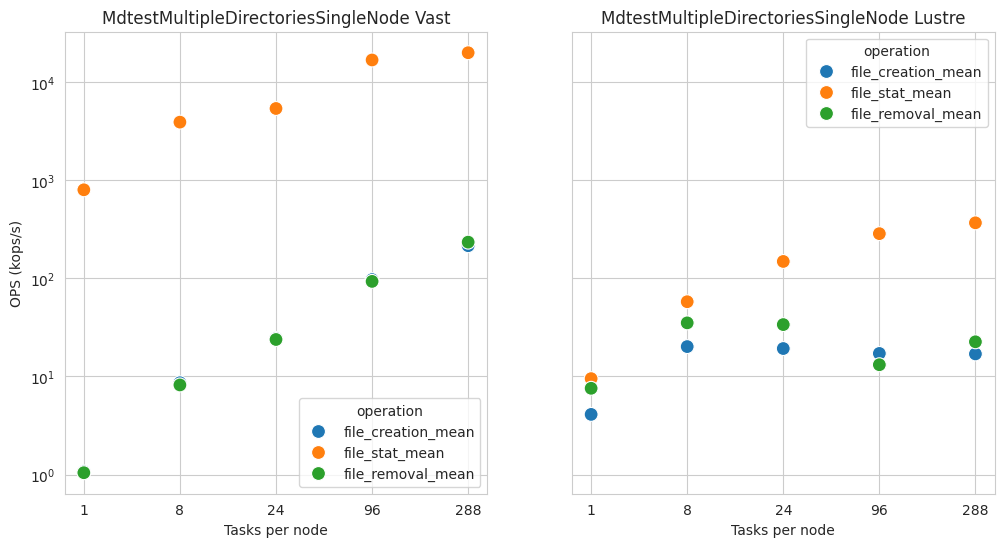

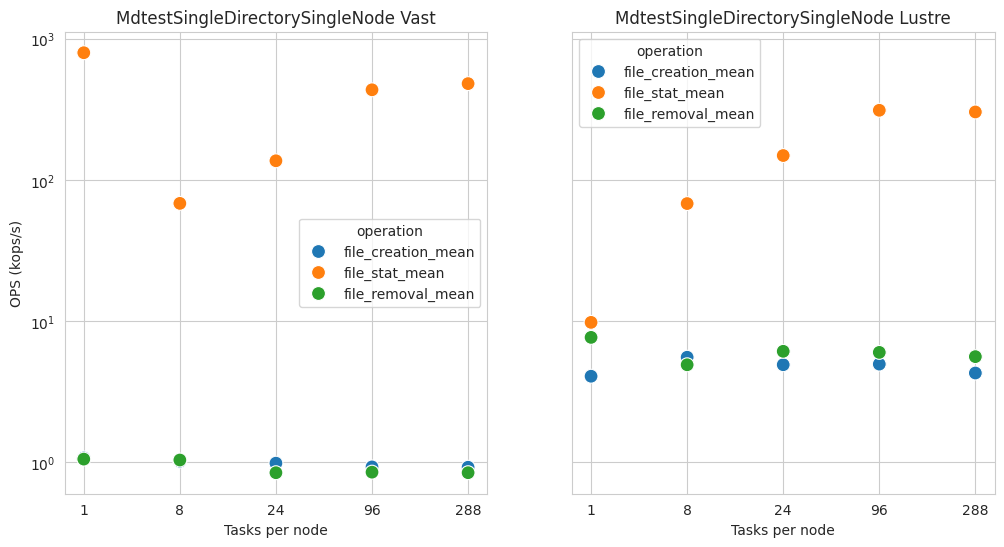

In [111]:
name=""
for name in ["MdtestMultipleDirectoriesSingleNode", "MdtestSingleDirectorySingleNode"]:
    plot_data=data.query(f"name=='{name}'")
    fig, axes = plt.subplots(1, 2, figsize=(12, 6),sharey=True)
    for i,filesystem in enumerate(["vast","lustre"]):
        sns.scatterplot(ax=axes[i], data=plot_data.query(f"filesystem=='{filesystem}'"), x="tasks_per_node", y="kops",hue="operation",s=100)
        axes[i].set_ylabel("OPS (kops/s)")
        axes[i].set_xlabel("Tasks per node")
        axes[i].set_yscale("log")
        axes[i].set_title(f"{name} {filesystem.capitalize()}")
    plt.savefig(f"{name}_performance.png", dpi=300, bbox_inches="tight")

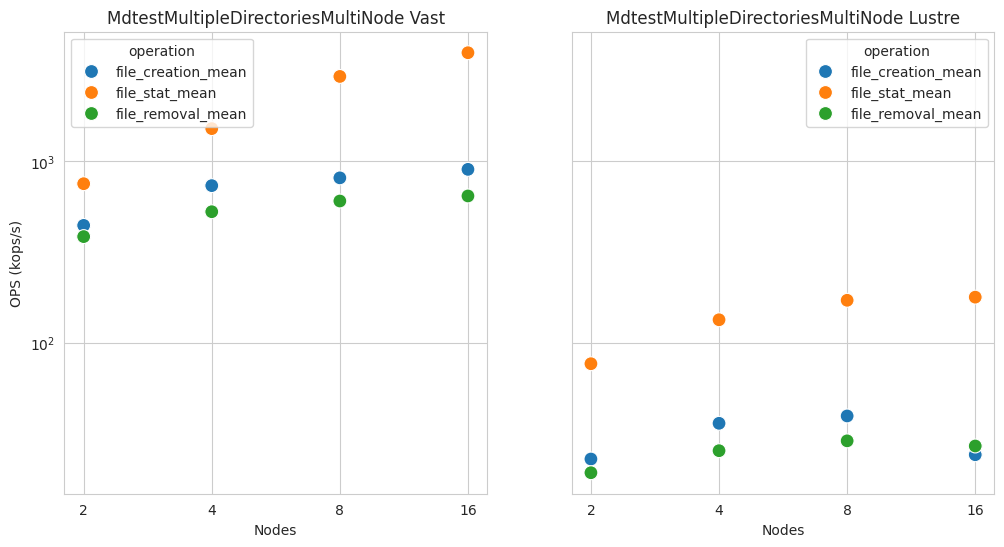

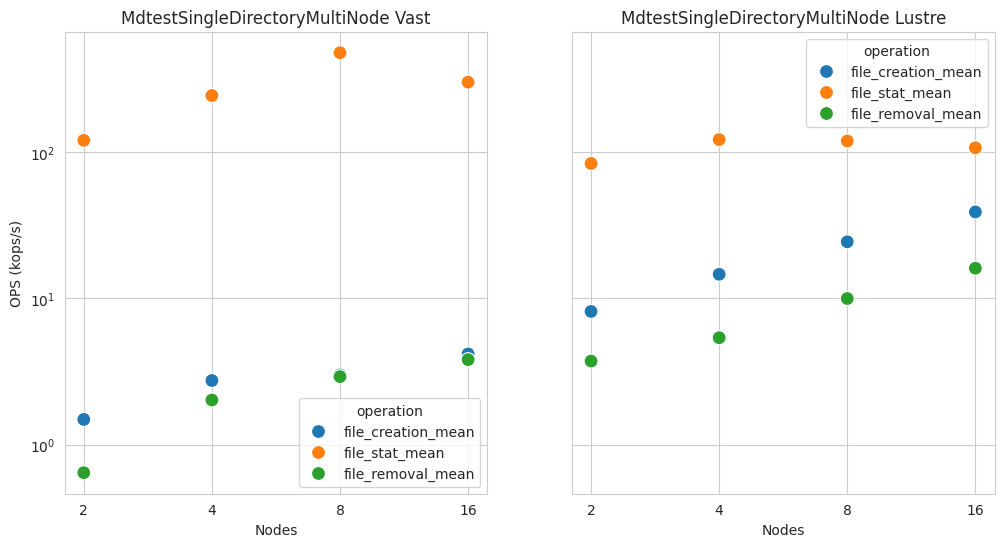

In [147]:
name=""
for name in ["MdtestMultipleDirectoriesMultiNode", "MdtestSingleDirectoryMultiNode"]:
    plot_data=data.query(f"name=='{name}'")
    fig, axes = plt.subplots(1, 2, figsize=(12, 6),sharey=True)
    for i,filesystem in enumerate(["vast","lustre"]):
        sns.scatterplot(ax=axes[i], data=plot_data.query(f"filesystem=='{filesystem}'"), x="nodes", y="kops",hue="operation",s=100)
        axes[i].set_ylabel("OPS (kops/s)")
        axes[i].set_xlabel("Nodes")
        axes[i].set_yscale("log")
        axes[i].set_title(f"{name} {filesystem.capitalize()}")
    plt.savefig(f"{name}_performance.png", dpi=300, bbox_inches="tight")

# Results from the Nemo benchmark

These are results from the nemo benchamrck. This is a version of the GYRE_PRISCES benchmark, at 1/12 degree resolution, but with the amount of data written increased. 

In [148]:
data=pd.read_csv(os.path.join(base_path,"nemo_io_performance.csv"))

In [149]:

_data=data.groupby(["filesystem","mode"]).aggregate({"bandwidth_H5D":["mean","std"]}).reset_index()
# move the filesystem column values to column names
_data

filesystem        mode bandwidth_H5D          
                                  mean       std
0     lustre  multi_file     20.029640  0.388510
1     lustre    one_file      1.525681  0.148879
2       vast  multi_file     94.319698  1.211911
3       vast    one_file      0.677148  0.290325

The performance seems to be better on VAST in the multi_file mode ( each process creates a single file) , but not on the one_file method, where the bandwidth is significantly smaller.